# Capítulo 5: IA para la Automatización de la Respuesta a Incidentes

**Guía Técnica:** Inteligencia Artificial en Ciberseguridad  
**Mayo 2026**

---

## 5.1. Introducción

La IA puede integrarse en sistemas **SIEM** (*Security Information and Event Management*) para agilizar la identificación, contención y resolución de incidentes, reduciendo el **MTTR** (*Mean Time To Respond*).

### Cadena de dependencias

```
Cap. 03 ─ Isolation Forest ──► anomalia_red      ─┐
                                                   ├─► incident_data.csv ─► SVM ─► Orquestación
Cap. 04 ─ Random Forest    ──► malware_detectado  ─┘
```

> **Requisito:** ejecutar los Capítulos 03 y 04 antes de este cuaderno para generar los modelos en `../models/`.

### Contenido
| Sección | Técnica |
|---|---|
| 5.0 | Carga de modelos de Cap. 03 y 04 |
| 5.1 | Generación de `incident_data.csv` con señales reales |
| 5.2 | Clasificación de severidad con SVM |
| 5.3 | Motor de orquestación de respuesta |

---
## Sección 0: Carga de modelos de capítulos anteriores

In [8]:
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

MODELS_DIR = Path("../models")
DATA_DIR   = Path("../data")

# --- Modelos del Capítulo 03 ---
model_if  = joblib.load(MODELS_DIR / "isolation_forest.pkl")
scaler    = joblib.load(MODELS_DIR / "scaler_red.pkl")

# --- Modelo del Capítulo 04 ---
rf_malware    = joblib.load(MODELS_DIR / "random_forest_malware.pkl")
malware_cols  = joblib.load(MODELS_DIR / "malware_feature_cols.pkl")

print("Modelos cargados correctamente:")
print(f"  Cap. 03 → {type(model_if).__name__} + {type(scaler).__name__}")
print(f"  Cap. 04 → {type(rf_malware).__name__} ({len(malware_cols)} features)")

Modelos cargados correctamente:
  Cap. 03 → IsolationForest + MinMaxScaler
  Cap. 04 → RandomForestClassifier (12 features)


---
## Sección 1: Generación de `incident_data.csv`

Construimos el dataset de incidentes aplicando los modelos entrenados sobre muestras de los datasets anteriores.
Cada incidente combina:
- **`anomalia_red`** → salida del Isolation Forest sobre `network_traffic.csv`
- **`malware_detectado`** → salida del Random Forest sobre `file_features.csv`
- Contexto sintético: hosts afectados, bytes exfiltrados, duración, privilegios
- **`severity`** → derivada por reglas realistas de SIEM (0=bajo … 3=crítico)

In [9]:
from sklearn.preprocessing import LabelEncoder

RNG = np.random.default_rng(seed=42)
N   = 1200

# --- Señal de red (Cap. 03) ---
df_red = pd.read_csv(DATA_DIR / "network_traffic.csv")
df_red["protocol"] = LabelEncoder().fit_transform(df_red["protocol"])
FEAT_RED = ["bytes_sent", "bytes_recv", "duration", "src_port", "dst_port", "protocol"]

idx_red       = RNG.integers(0, len(df_red), N)
X_red         = scaler.transform(df_red[FEAT_RED].iloc[idx_red])
pred_if       = model_if.predict(X_red)          # 1=normal | -1=anomalía
anomalia_red  = (pred_if == -1).astype(int)       # 0=normal | 1=anomalía

# --- Señal de malware (Cap. 04) ---
df_mal = pd.read_csv(DATA_DIR / "file_features.csv")
idx_mal          = RNG.integers(0, len(df_mal), N)
X_mal            = df_mal[malware_cols].iloc[idx_mal]
malware_detectado = rf_malware.predict(X_mal)     # 0=benigno | 1=malicioso

# --- Contexto sintético del incidente ---
num_hosts        = RNG.integers(1, 50, N)
tipo_evento      = RNG.integers(0, 4, N)          # 0=scan 1=malware 2=exfil 3=C2
bytes_exfil      = RNG.integers(0, 10_000_000, N).astype(float)
duracion_seg     = RNG.integers(1, 86400, N).astype(float)
priv_elevados    = RNG.integers(0, 2, N)

# --- Derivación de severidad (reglas SIEM) ---
def derivar_severidad(ar, md, hosts, priv, exfil):
    score = ar * 2 + md * 2 + priv + (hosts > 10) + (exfil > 1_000_000)
    return np.where(score >= 5, 3,
           np.where(score >= 3, 2,
           np.where(score >= 1, 1, 0)))

severity = derivar_severidad(
    anomalia_red, malware_detectado, num_hosts, priv_elevados, bytes_exfil
)

incidents = pd.DataFrame({
    "anomalia_red"       : anomalia_red,
    "malware_detectado"  : malware_detectado,
    "num_hosts_afectados": num_hosts,
    "tipo_evento_cod"    : tipo_evento,
    "bytes_exfiltrados"  : bytes_exfil,
    "duracion_seg"       : duracion_seg,
    "privilegios_elevados": priv_elevados,
    "severity"           : severity,
})

incidents.to_csv(DATA_DIR / "incident_data.csv", index=False)

print(f"incident_data.csv  →  {len(incidents):,} incidentes")
print(incidents["severity"].value_counts().sort_index()
      .rename({0:"Bajo",1:"Medio",2:"Alto",3:"Crítico"}).to_string())

incident_data.csv  →  1,200 incidentes
severity
Bajo        11
Medio      546
Alto       516
Crítico    127


Z:\Universidad\IXCICLO\Seguridad\IACIBERSEGURIDAD\env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


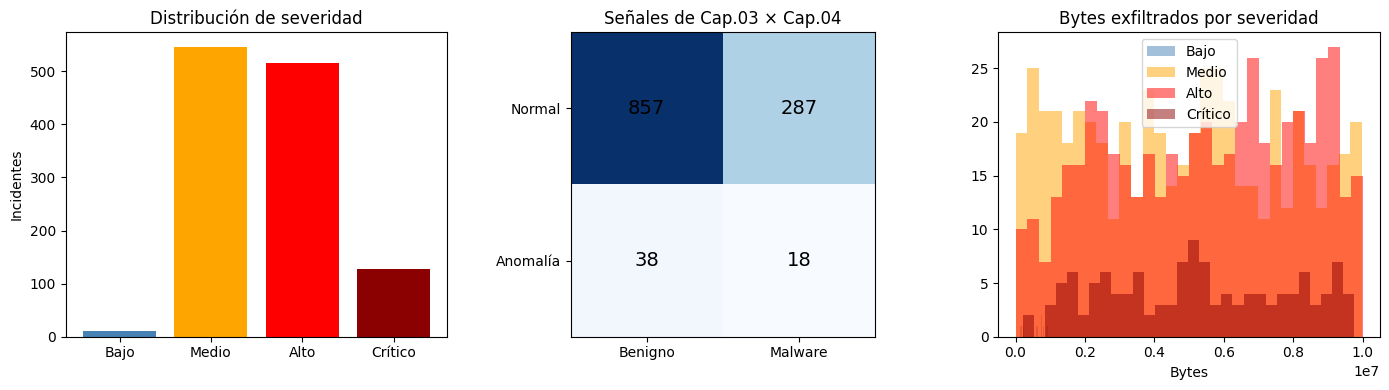

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Distribución de severidad
counts = incidents["severity"].value_counts().sort_index()
axes[0].bar(["Bajo","Medio","Alto","Crítico"], counts.values,
            color=["steelblue","orange","red","darkred"])
axes[0].set_title("Distribución de severidad")
axes[0].set_ylabel("Incidentes")

# Anomalía red vs malware detectado
crosstab = pd.crosstab(incidents["anomalia_red"], incidents["malware_detectado"],
                        rownames=["Anomalía red"], colnames=["Malware"])
axes[1].imshow(crosstab.values, cmap="Blues")
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(["Benigno","Malware"])
axes[1].set_yticks([0,1]); axes[1].set_yticklabels(["Normal","Anomalía"])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, crosstab.values[i,j], ha="center", va="center", fontsize=14)
axes[1].set_title("Señales de Cap.03 × Cap.04")

# Bytes exfiltrados por severidad
for sev, color in [(0,"steelblue"),(1,"orange"),(2,"red"),(3,"darkred")]:
    subset = incidents[incidents.severity==sev]["bytes_exfiltrados"]
    axes[2].hist(subset, bins=30, alpha=0.5, color=color,
                 label=["Bajo","Medio","Alto","Crítico"][sev])
axes[2].set_title("Bytes exfiltrados por severidad")
axes[2].set_xlabel("Bytes")
axes[2].legend()

plt.tight_layout()
plt.savefig(DATA_DIR / "incident_eda.png", dpi=150)
plt.show()

---
## 5.2. Triaje automático de incidentes

### 5.2.1. Clasificación de severidad con SVM

Un **SVM** con kernel RBF aprende a clasificar la severidad de nuevos incidentes a partir de sus características, integrando las señales de los modelos anteriores.

In [11]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

incidents = pd.read_csv(DATA_DIR / "incident_data.csv")
X = incidents.drop("severity", axis=1)
y = incidents["severity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Pipeline: escalado + SVM
pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=1.0, gamma="scale",
                   probability=True, random_state=42))
])
pipeline_svm.fit(X_train, y_train)

y_pred = pipeline_svm.predict(X_test)
etiquetas = ["Bajo", "Medio", "Alto", "Crítico"]

print("=== Reporte de clasificación — SVM ===")
print(classification_report(y_test, y_pred, target_names=etiquetas))

=== Reporte de clasificación — SVM ===
              precision    recall  f1-score   support

        Bajo       0.00      0.00      0.00         2
       Medio       0.96      0.96      0.96       109
        Alto       0.94      0.96      0.95       103
     Crítico       0.92      0.92      0.92        26

    accuracy                           0.95       240
   macro avg       0.71      0.71      0.71       240
weighted avg       0.94      0.95      0.95       240



Z:\Universidad\IXCICLO\Seguridad\IACIBERSEGURIDAD\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Z:\Universidad\IXCICLO\Seguridad\IACIBERSEGURIDAD\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Z:\Universidad\IXCICLO\Seguridad\IACIBERSEGURIDAD\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

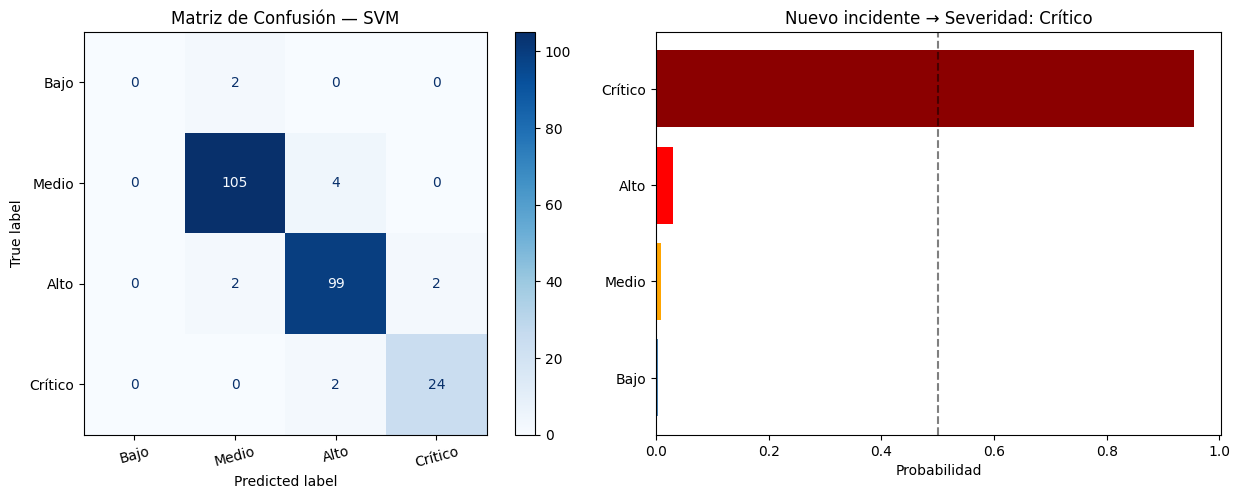


Incidente de prueba → Severidad predicha: Crítico
  P(Bajo    ) = 0.004
  P(Medio   ) = 0.010
  P(Alto    ) = 0.031
  P(Crítico ) = 0.955


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=etiquetas
).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Matriz de Confusión — SVM")
axes[0].tick_params(axis="x", rotation=15)

# Probabilidades para un incidente nuevo de prueba
nuevo = pd.DataFrame([{
    "anomalia_red"        : 1,
    "malware_detectado"   : 1,
    "num_hosts_afectados" : 15,
    "tipo_evento_cod"     : 2,
    "bytes_exfiltrados"   : 3_500_000,
    "duracion_seg"        : 3600,
    "privilegios_elevados": 1,
}])
proba = pipeline_svm.predict_proba(nuevo)[0]
pred  = pipeline_svm.predict(nuevo)[0]

axes[1].barh(etiquetas, proba, color=["steelblue","orange","red","darkred"])
axes[1].set_xlabel("Probabilidad")
axes[1].set_title(f"Nuevo incidente → Severidad: {etiquetas[int(pred)]}")
axes[1].axvline(0.5, color="black", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(DATA_DIR / "svm_resultados.png", dpi=150)
plt.show()

print(f"\nIncidente de prueba → Severidad predicha: {etiquetas[int(pred)]}")
for i, p in enumerate(proba):
    print(f"  P({etiquetas[i]:<8}) = {p:.3f}")

---
## 5.3. Orquestación de respuestas

Una vez clasificado el incidente, Python orquesta acciones automáticas según la severidad:

| Severidad | Acciones automáticas |
|---|---|
| Bajo (0) | Registrar y monitorear |
| Medio (1) | Notificar al equipo |
| Alto (2) | Bloquear IP + Notificar |
| Crítico (3) | Aislar sistema + Bloquear IP + Notificar |

In [13]:
import logging
from dataclasses import dataclass
from enum import IntEnum

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)-8s %(message)s"
)

class Severidad(IntEnum):
    BAJO    = 0
    MEDIO   = 1
    ALTO    = 2
    CRITICO = 3

@dataclass
class Incidente:
    id_sistema  : str
    ip_origen   : str
    severidad   : Severidad
    descripcion : str

# Simulamos llamadas a la API de la plataforma SOAR
def aislar_sistema(sistema_id: str) -> bool:
    logging.info(f"[SOAR] Aislando sistema {sistema_id}...")
    return True  # En producción: requests.post(f"{BASE_URL}/isolate/{sistema_id}")

def bloquear_ip(ip: str) -> bool:
    logging.info(f"[FIREWALL] Bloqueando IP {ip}...")
    return True  # En producción: requests.post(f"{BASE_URL}/firewall/block", json={"ip": ip})

def notificar_equipo(incidente: Incidente) -> None:
    logging.info(
        f"[ALERTA] Severidad={incidente.severidad.name} "
        f"Sistema={incidente.id_sistema} IP={incidente.ip_origen}"
    )

def orquestar_respuesta(incidente: Incidente) -> None:
    """Selecciona y ejecuta acciones según la severidad del incidente."""
    logging.info(f"Procesando incidente en {incidente.id_sistema}")

    if incidente.severidad == Severidad.BAJO:
        logging.info("Acción: registrar y monitorear.")

    elif incidente.severidad == Severidad.MEDIO:
        notificar_equipo(incidente)

    elif incidente.severidad == Severidad.ALTO:
        bloquear_ip(incidente.ip_origen)
        notificar_equipo(incidente)

    elif incidente.severidad == Severidad.CRITICO:
        aislar_sistema(incidente.id_sistema)
        bloquear_ip(incidente.ip_origen)
        notificar_equipo(incidente)

print("Motor de orquestación definido correctamente.")

Motor de orquestación definido correctamente.


In [17]:
# Simulación: clasificar y responder a 4 incidentes de prueba
casos_prueba = [
    Incidente("SRV-DEV-01",  "10.0.1.5",   Severidad.BAJO,    "Escaneo interno leve."),
    Incidente("WS-USER-22",  "192.168.5.44",Severidad.MEDIO,   "Acceso inusual a RRHH."),
    Incidente("SRV-WEB-03",  "45.33.32.156",Severidad.ALTO,    "Tráfico C2 detectado."),
    Incidente("SRV-PROD-042","91.108.4.1",  Severidad.CRITICO, "Exfiltración masiva con malware."),
]

print("=" * 60)
for inc in casos_prueba:
    orquestar_respuesta(inc)
    print("-" * 60)

2026-05-06 23:47:45,675 INFO     Procesando incidente en SRV-DEV-01
2026-05-06 23:47:45,675 INFO     Acción: registrar y monitorear.
2026-05-06 23:47:45,676 INFO     Procesando incidente en WS-USER-22
2026-05-06 23:47:45,677 INFO     [ALERTA] Severidad=MEDIO Sistema=WS-USER-22 IP=192.168.5.44
2026-05-06 23:47:45,677 INFO     Procesando incidente en SRV-WEB-03
2026-05-06 23:47:45,678 INFO     [FIREWALL] Bloqueando IP 45.33.32.156...
2026-05-06 23:47:45,679 INFO     [ALERTA] Severidad=ALTO Sistema=SRV-WEB-03 IP=45.33.32.156


------------------------------------------------------------
------------------------------------------------------------


2026-05-06 23:47:45,704 INFO     Procesando incidente en SRV-PROD-042
2026-05-06 23:47:45,704 INFO     [SOAR] Aislando sistema SRV-PROD-042...
2026-05-06 23:47:45,705 INFO     [FIREWALL] Bloqueando IP 91.108.4.1...
2026-05-06 23:47:45,705 INFO     [ALERTA] Severidad=CRITICO Sistema=SRV-PROD-042 IP=91.108.4.1


------------------------------------------------------------
------------------------------------------------------------


---
## Persistencia de modelos → Capítulo 10

Guardamos el **pipeline SVM** para integrarlo en el Pipeline completo del Capítulo 10.

In [15]:
MODELS_DIR = Path("../models")
joblib.dump(pipeline_svm, MODELS_DIR / "svm_severity.pkl")

print("Modelos guardados en ../models/")
print("  svm_severity.pkl  → cargado en Cap. 10")

Modelos guardados en ../models/
  svm_severity.pkl  → cargado en Cap. 10


---
**Siguiente:** Capítulo 6 → Análisis de Comportamiento de Usuarios (UBA)